# Comparing PySIPS Priors: Uniform, BMS, and Katz

This notebook compares the three available prior distributions in `pysips.priors`:

| Prior | Class | Description | Reference
|---|---|---|---|
| **Uniform** | `ImproperUniformPrior` | Improper uniform — assigns log P = 0 to every expression | Bomarito and Leser (2026) |
| **BMS** | `BMSPrior` | Bayesian Machine Scientist; scores by weighted operator counts (Wikipedia-fit defaults) | Guimera et al. (2020) |
| **Katz** | `KatzPrior` | Katz back-off n-gram language model on operator trees; n=2, Wikipedia-fit default | Bartlett et al. (2024) |

**Sections**
1. Construct the priors
2. Log-prior comparison table on a few hand-picked expressions
3. Distribution comparison on 1000 randomly-generated expressions (histograms and 2D histograms)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LogNorm
from sympy import sympify

from bingo.expressions.agraph import AGraphExpression
from bingo.expressions import ComponentGenerator, AGraphGenerator
from bingo.expressions.agraph.pyagraph import (
    ADDITION, SUBTRACTION, MULTIPLICATION, DIVISION,
    SIN, COS, EXPONENTIAL, LOGARITHM, POWER,
    IS_ARITY_2_ARRAY, IS_TERMINAL_ARRAY,
)

from pysips.priors import (
    ImproperUniformPrior,
    BMSPrior,
    DEFAULT_BMS_WEIGHTS,
    DEFAULT_BMS_SQUARED_WEIGHTS,
    KatzPrior,
    load_default_katz_model,
)

rng = np.random.default_rng(42)
np.random.seed(42)

## 1. Construct the priors

All three priors use defaults drawn from (or consistent with) the **Wikipedia named-equations corpus**.

- The **BMS** prior uses `DEFAULT_BMS_WEIGHTS` / `DEFAULT_BMS_SQUARED_WEIGHTS` — the pre-fit weight vectors stored in `pysips.priors.bms_prior`.
- The **Katz** prior loads `default_katz_n2_wikipedia.json` — saved by `load_default_katz_model(n=2)`.
- The **Uniform** prior is a thin wrapper: `logpdf` always returns 0.

In [2]:
X_DIM = 2  # number of input variables used throughout

# --- Uniform ---
# ImproperUniformPrior needs a generator; we don't use sampling here,
# so pass a minimal placeholder.  logpdf always returns 0.
def _dummy_gen():
    """Never called for scoring — only needed if rvs() is used."""
    raise NotImplementedError

uniform_prior = ImproperUniformPrior(_dummy_gen)

# Helper: uniform log-prob is always 0 regardless of the expression.
def uniform_logpdf_single(_ag):
    return 0.0

# --- BMS (Wikipedia-fit defaults) ---
bms_prior = BMSPrior(
    weights=DEFAULT_BMS_WEIGHTS,
    squared_weights=DEFAULT_BMS_SQUARED_WEIGHTS,
    x_dim=X_DIM,
)

# --- Katz n=2 (Wikipedia default) ---
katz_model = load_default_katz_model(n=2)
katz_prior = KatzPrior(katz_model, x_dim=X_DIM)

print("Priors constructed.")
print(f"  Katz model n={katz_prior.n}, vocab size={len(katz_model.left_model.vocabulary)}")

Priors constructed.
  Katz model n=2, vocab size=20


## 2. Log-prior comparison on example expressions

We score three hand-picked expressions that differ in structure and complexity:

| Expression | Description |
|---|---|
| `X_0 + X_1` | Linear sum — simple, two terminals |
| `sin(X_0) + sin(X_1)` | Sum of sines — motivating example from Bartlett et al. |
| `exp(-X_0**2) * X_1` | Gaussian-like product — deeper tree |

In [3]:
EXAMPLE_EXPRS = [
    ("X_0 + X_1",             "simple linear sum"),
    ("sin(X_0) + sin(X_1)",   "sum of sines"),
    ("exp(-X_0**2) * X_1",    "Gaussian-like product"),
]

priors_map = [
    ("Uniform",  uniform_logpdf_single),
    ("BMS",      bms_prior._logpdf_single),
    ("Katz n=2", katz_prior._logpdf_single),
]

# Header
col_w = 28
header = f"{'Expression':<{col_w}}" + "".join(f"{name:>12}" for name, _ in priors_map)
print(header)
print("-" * len(header))

for expr_str, desc in EXAMPLE_EXPRS:
    ag = AGraphExpression(equation=expr_str)
    scores = [fn(ag) for _, fn in priors_map]
    row = f"{expr_str:<{col_w}}" + "".join(f"{s:>12.3f}" for s in scores)
    print(row)

print()
print("(Uniform is always 0; higher BMS/Katz values = more probable under that prior)")

Expression                       Uniform         BMS    Katz n=2
----------------------------------------------------------------
X_0 + X_1                          0.000       0.448      -5.078
sin(X_0) + sin(X_1)                0.000      -5.444     -20.049
exp(-X_0**2) * X_1                 0.000       0.748     -12.821

(Uniform is always 0; higher BMS/Katz values = more probable under that prior)


### The paper's motivating example: nested vs sum-of-sines

Bartlett et al. argue that `sin(x₀)+sin(x₁)` should be *more probable* than `sin(sin(x₀+x₁))`
under a parent-conditioned prior (n ≥ 2), even though both have the same node counts.

In [4]:
nested    = AGraphExpression(equation="sin(sin(X0 + X1))")
sum_sines = AGraphExpression(equation="sin(X0) + sin(X1)")

print(f"{'Prior':<12}  {'sin(sin(x+y))':>18}  {'sin(x)+sin(y)':>18}  {'prefer sum?':>12}")
for name, fn in priors_map:
    a = fn(nested)
    b = fn(sum_sines)
    mark = "yes" if b > a else ("tie" if b == a else "NO")
    print(f"{name:<12}  {a:>18.4f}  {b:>18.4f}  {mark:>12}")

Prior              sin(sin(x+y))       sin(x)+sin(y)   prefer sum?
Uniform                   0.0000              0.0000           tie
BMS                      -5.4444             -5.4444           tie
Katz n=2                -20.7802            -20.0486           yes


## 3. Distribution comparison on randomly-generated expressions

We generate **10000 unique** `AGraphExpression`s with DAG complexity < 16 using bingo's
standard `AGraphGenerator`, then score each expression under all three priors.

Operators: `{+, -, ×, ÷, sin, cos, exp, log, pow}` — a broad basis present in both the
BMS weight dictionary and the Katz vocabulary.

In [17]:
MAX_COMPLEXITY = 16   # DAG node count upper bound
N_TARGET       = 10000
OPERATORS      = [ADDITION, SUBTRACTION, MULTIPLICATION, DIVISION,
                  SIN, COS, EXPONENTIAL, LOGARITHM, POWER]

unique_exprs = set()
cg = ComponentGenerator(
    input_x_dimension=X_DIM,
    terminal_probability=0.1,
    constant_probability=0.3,
)
for op in OPERATORS:
    cg.add_operator(op)
generator = AGraphGenerator(MAX_COMPLEXITY*3//2, MAX_COMPLEXITY*3//2, cg)

attempts = 0
while len(unique_exprs) < N_TARGET and attempts < 100 * N_TARGET:
    ag = generator()
    attempts += 1
    if ag.complexity < MAX_COMPLEXITY:
        unique_exprs.add(ag)

agraphs = list(unique_exprs)[:N_TARGET]
complexities = np.array([ag.complexity for ag in agraphs])
print(f"Generated {len(agraphs)} unique expressions")
print(f"  DAG complexity: min={complexities.min()}, max={complexities.max()}, "
      f"mean={complexities.mean():.2f}")

Generated 10000 unique expressions
  DAG complexity: min=1, max=15, mean=7.18


In [18]:
logp_uniform = np.zeros(len(agraphs))   # always 0
logp_bms     = np.array([bms_prior._logpdf_single(ag)  for ag in agraphs])
logp_katz    = np.array([katz_prior._logpdf_single(ag) for ag in agraphs])

scores = {"Uniform": logp_uniform, "BMS": logp_bms, "Katz n=2": logp_katz}

print("Summary statistics (log P):")
print(f"{'Prior':<12}  {'mean':>10}  {'std':>10}  {'min':>10}  {'max':>10}  {'finite':>8}")
for name, lp in scores.items():
    fin = lp[np.isfinite(lp)]
    print(f"{name:<12}  {fin.mean():>10.3f}  {fin.std():>10.3f}  "
          f"{fin.min():>10.3f}  {fin.max():>10.3f}  {len(fin):>5}/{len(lp)}")

Summary statistics (log P):
Prior               mean         std         min         max    finite
Uniform            0.000       0.000       0.000       0.000  10000/10000
BMS               -5.619       5.933    -124.059       6.768  10000/10000
Katz n=2         -38.003      23.398    -311.989      -0.674  10000/10000


### 3a. Marginal histograms

Each panel shows the distribution of log P values under one prior, evaluated on the same
set of random expressions.  The Uniform prior collapses to a single spike at 0.  For BMS
and Katz, expressions with operators that are rare in the Wikipedia corpus receive low
(very negative) log-probabilities.

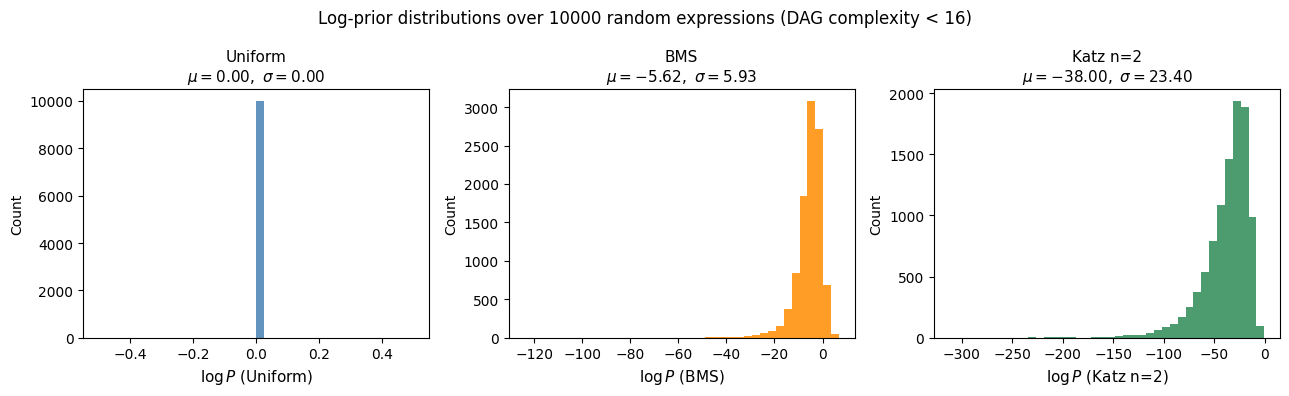

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=False)
colors = {"Uniform": "steelblue", "BMS": "darkorange", "Katz n=2": "seagreen"}

for ax, (name, lp) in zip(axes, scores.items()):
    fin = lp[np.isfinite(lp)]
    ax.hist(fin, bins=40, color=colors[name], edgecolor="none", alpha=0.85)
    ax.set_xlabel(rf"$\log P$ ({name})", fontsize=11)
    ax.set_ylabel("Count", fontsize=10)
    ax.set_title(f"{name}\n"
                 rf"$\mu={fin.mean():.2f},\ \sigma={fin.std():.2f}$",
                 fontsize=11)
    n_inf = int((~np.isfinite(lp)).sum())
    if n_inf:
        ax.annotate(f"{n_inf} −∞ excluded", xy=(0.97, 0.95), xycoords="axes fraction",
                    ha="right", va="top", fontsize=9, color="red")

fig.suptitle(f"Log-prior distributions over {len(agraphs)} random expressions"
             f" (DAG complexity < {MAX_COMPLEXITY})", fontsize=12)
plt.tight_layout()
plt.show()

### 3b. Pairwise 2D histograms

Each panel below shows how one prior's log P compares to another across the same set of
expressions.  A diagonal cloud indicates high correlation; a scattered cloud means the
priors disagree about which expressions are probable.  Expressions that are −∞ under
either prior (Katz OOV) are excluded from each panel individually.

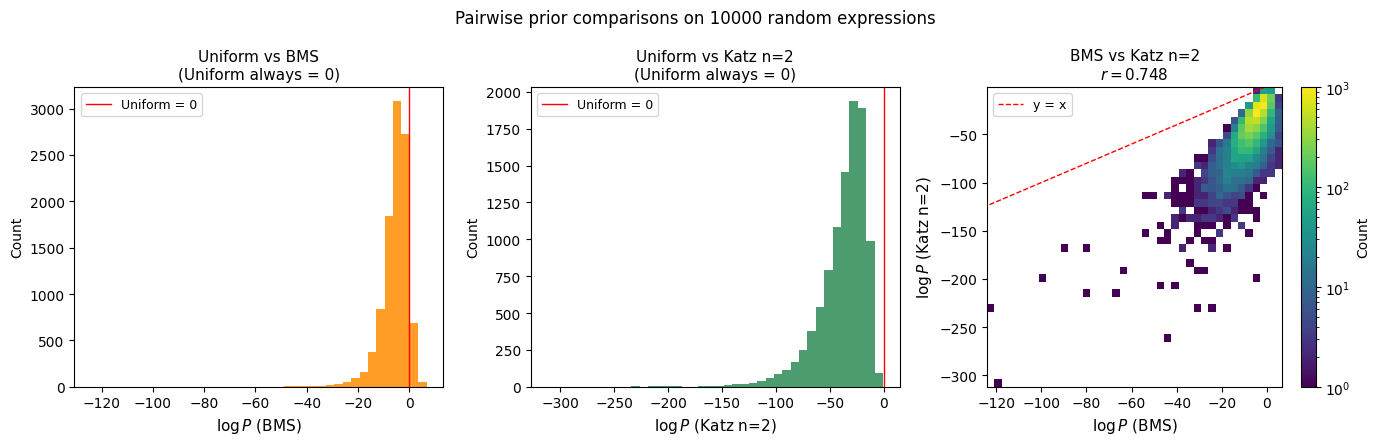

Pearson r(BMS, Katz n=2) on 10000 finite expressions: 0.7482


In [20]:
prior_names = ["BMS", "Katz n=2"]   # Uniform vs uniform is trivial
all_names   = list(scores.keys())    # ["Uniform", "BMS", "Katz n=2"]

# We make a 2×2 comparison grid: each non-trivial pair
pairs = [
    ("Uniform", "BMS"),
    ("Uniform", "Katz n=2"),
    ("BMS",     "Katz n=2"),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
for ax, (nx, ny) in zip(axes, pairs):
    lx, ly = scores[nx], scores[ny]
    fin = np.isfinite(lx) & np.isfinite(ly)
    x, y = lx[fin], ly[fin]

    if nx == "Uniform":
        # Uniform is constant — show as a 1D histogram instead
        ax.hist(y, bins=40, color=colors[ny], alpha=0.85, edgecolor="none",
                orientation="vertical")
        ax.axvline(0, color="red", lw=1, label="Uniform = 0")
        ax.set_xlabel(rf"$\log P$ ({ny})", fontsize=11)
        ax.set_ylabel("Count", fontsize=10)
        ax.set_title(f"Uniform vs {ny}\n(Uniform always = 0)", fontsize=11)
        ax.legend(fontsize=9)
    else:
        h = ax.hist2d(x, y, bins=40, cmap="viridis", norm=LogNorm())
        plt.colorbar(h[3], ax=ax, label="Count")
        mn = min(x.min(), y.min())
        mx = max(x.max(), y.max())
        ax.plot([mn, mx], [mn, mx], "r--", lw=1, label="y = x")
        r = np.corrcoef(x, y)[0, 1]
        ax.set_xlabel(rf"$\log P$ ({nx})", fontsize=11)
        ax.set_ylabel(rf"$\log P$ ({ny})", fontsize=11)
        ax.set_title(f"{nx} vs {ny}\n" + rf"$r={r:.3f}$", fontsize=11)
        ax.legend(fontsize=9)

fig.suptitle(f"Pairwise prior comparisons on {len(agraphs)} random expressions", fontsize=12)
plt.tight_layout()
plt.show()

# Print Pearson r for the non-trivial pair
fin = np.isfinite(logp_bms) & np.isfinite(logp_katz)
r = np.corrcoef(logp_bms[fin], logp_katz[fin])[0, 1]
print(f"Pearson r(BMS, Katz n=2) on {fin.sum()} finite expressions: {r:.4f}")